In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("../../Data/Raw/dataset-6ab002b01f9ef078223946.csv")

# Data Cleaning

** We start by filling Teacher_quality by the most frequest value in this data Set wich is "medium"

In [11]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Teacher_Quality'].isna().sum()

np.int64(0)

** Now we treat an outlier value where the exam score of a student is higher than 100 , 101 to be exact , to handle that we can cap the max score to 100 using .clip()

In [12]:
df['Exam_Score'] = df['Exam_Score'].clip(lower=0, upper=100)

** Detecting outliers on Exam_Score with IQR bounds and removing rows outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] **

IQR bounds: [59.0, 75.0]
IQR outliers: 104


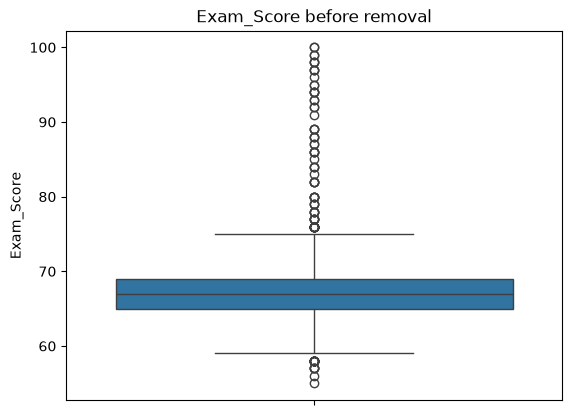

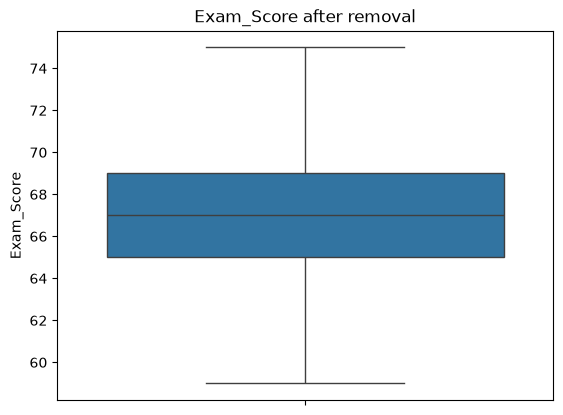

In [13]:
Q1 = df['Exam_Score'].quantile(0.25)
Q3 = df['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print(f'IQR bounds: [{lower}, {upper}]')
print(f'IQR outliers: {((df["Exam_Score"] < lower) | (df["Exam_Score"] > upper)).sum()}')

sns.boxplot(y=df['Exam_Score'])
plt.title('Exam_Score before removal')
plt.show()

df = df[(df['Exam_Score'] >= lower) & (df['Exam_Score'] <= upper)]

sns.boxplot(y=df['Exam_Score'])
plt.title('Exam_Score after removal')
plt.show()

u** Now We treat missing values of Distance from home , we can replace the missing values with the most frequent value wich is in the case , "near"

In [14]:
df['Distance_from_Home']=df['Distance_from_Home'].fillna(
    df['Distance_from_Home'].mode()[0])

** Another issue we have is that we have bunch missing values for Parental Education level , we can fix that by just replacing the values with our most frequent value for this column

In [15]:
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])

** We check if all missing values where sorted out

In [16]:
df.isna().sum().to_string()

'Hours_Studied                 0\nAttendance                    0\nParental_Involvement          0\nAccess_to_Resources           0\nExtracurricular_Activities    0\nSleep_Hours                   0\nPrevious_Scores               0\nMotivation_Level              0\nInternet_Access               0\nTutoring_Sessions             0\nFamily_Income                 0\nTeacher_Quality               0\nSchool_Type                   0\nPeer_Influence                0\nPhysical_Activity             0\nLearning_Disabilities         0\nParental_Education_Level      0\nDistance_from_Home            0\nGender                        0\nExam_Score                    0'

** Encoding categoricals and re-computing the correlation matrix **

/tmp/ipykernel_82193/1202340510.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_enc = df.replace(ordinal_map)


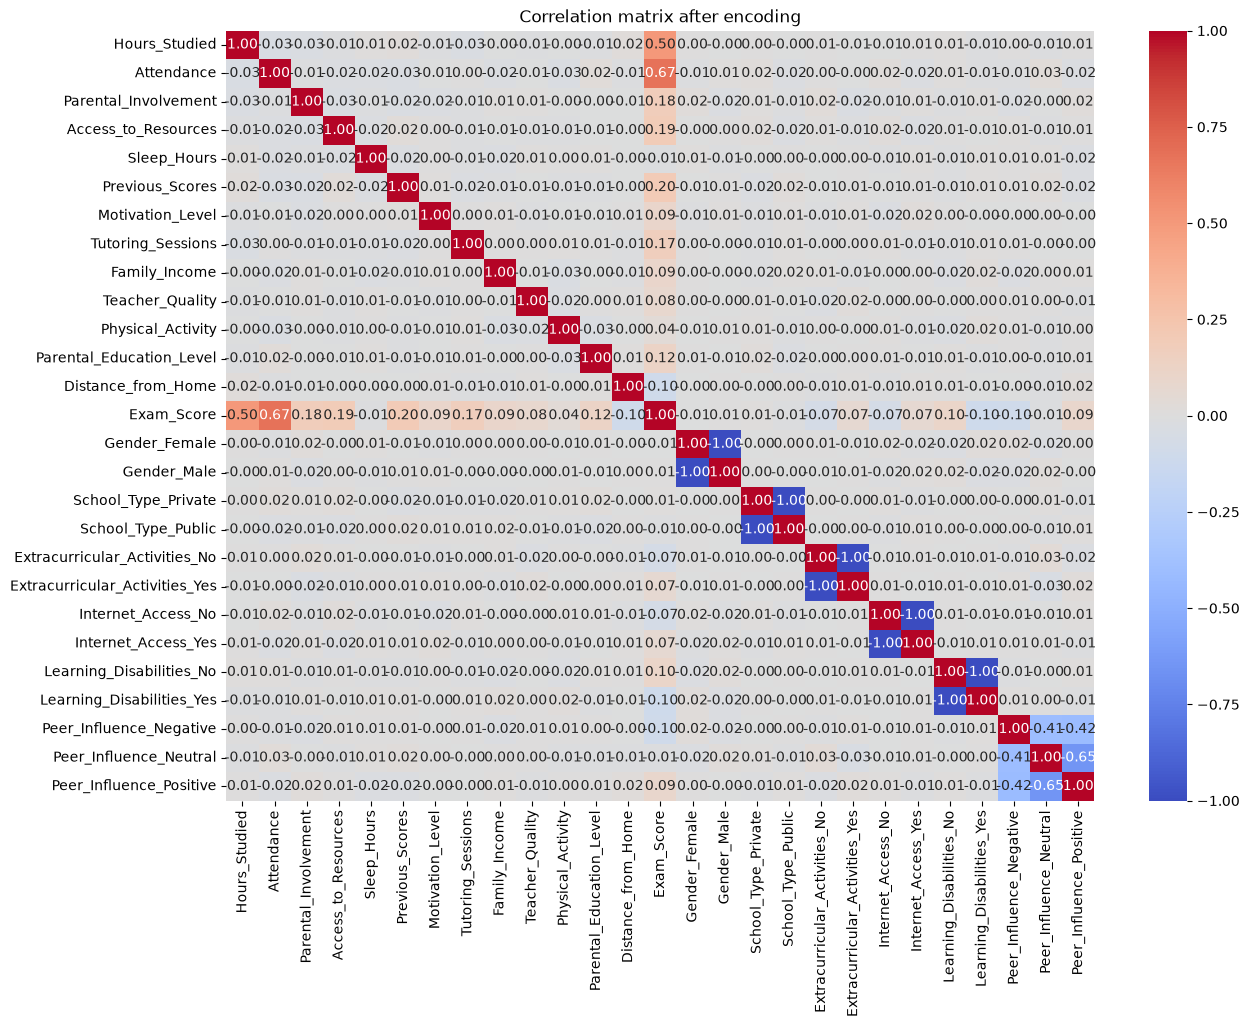

In [17]:
ordinal_map = {
    'Parental_Involvement': {'Low': 1, 'Medium': 2, 'High': 3},
    'Access_to_Resources': {'Low': 1, 'Medium': 2, 'High': 3},
    'Motivation_Level': {'Low': 1, 'Medium': 2, 'High': 3},
    'Family_Income': {'Low': 1, 'Medium': 2, 'High': 3},
    'Teacher_Quality': {'Low': 1, 'Medium': 2, 'High': 3},
    'Parental_Education_Level': {'High School': 1, 'College': 2, 'Postgraduate': 3},
    'Distance_from_Home': {'Near': 1, 'Moderate': 2, 'Far': 3},
}
df_enc = df.replace(ordinal_map)

nominal = ['Gender', 'School_Type', 'Extracurricular_Activities',
           'Internet_Access', 'Learning_Disabilities', 'Peer_Influence']
df_enc = pd.get_dummies(df_enc, columns=nominal)

plt.figure(figsize=(14, 10))
sns.heatmap(df_enc.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix after encoding')
plt.show()

** Now we can save the clean Data as a csv file for future use**

In [18]:
df.to_csv("../../Data/Processed/clean_data.csv", index=False)
df_enc.to_csv("../../Data/Processed/clean_data_encoded.csv", index=False)